# Maestría en Ciencia de Datos
## Universidad Tecnológica de la Mixteca

---
# Proyecto:Modelo recomendador espectrógráfico para audios musicales

**Autora:** Angelica Margarita Flores Islas  
**Asesor:** Dr. Tomás Pérez Becerra  
**Institución:** Universidad Tecnológica de la Mixteca (UTM)  
**Fecha:** Abril, 2026  

---

## 1. Descripción del Proyecto
Este proyecto desarrolla un sistema de recomendación musical optimizado mediante una arquitectura híbrida. A diferencia de los recomendadores tradicionales que realizan búsquedas globales, esta implementación utiliza una segmentación previa del espacio acústico para mejorar la eficiencia computacional y la relevancia tímbrica de las sugerencias.

---

## 2. Estructura del Notebook
El flujo de trabajo está organizado en los siguientes módulos:

1. **Ingesta y Curación:** Carga de características extraídas con `Librosa` y filtrado estadístico de señales no musicales.
2. **Ingeniería de Características:** Aplicación de `StandardScaler` y `RobustScaler`, seguida de la reducción de dimensionalidad con **PCA**.
3. **Clustering:** Entrenamiento y evaluación de clústeres (Métrica de Silueta y visualización t-SNE).
4. **Sistema de Recomendación:** Implementación de la lógica híbrida y evaluación de latencia vs. K-NN estándar.
5. **Visualización de Resultados:** Análisis de la cercanía acústica y comparativa de

## Librerías

In [138]:
from googleapiclient.discovery import build
from google.colab import auth
from google.colab import drive
from google.colab import files

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler, StandardScaler
from scipy.stats import skew

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import random
import seaborn as sns
import time



## Lectura de datos

In [2]:
df = pd.read_csv("/content/drive/MyDrive/AnteproyectoTerminal/Código/features.csv", index_col='id')

## Exploración de datos

### Descripción de datos

In [3]:
df.head()

,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,zero_crossing_rate_mean,zero_crossing_rate_var,rms_mean,rms_var,...,mfcc12_var,mfcc13_var,mfcc14_var,mfcc15_var,mfcc16_var,mfcc17_var,mfcc18_var,mfcc19_var,mfcc20_var,tempo
id,,,,,,,,,,,,,,,,,,,,,
2,2840.239528,816858.478217,2511.850072,110867.955555,5829.265659,1.965087e+06,0.156300,0.007739,0.145500,0.006246,...,10.977841,8.723879,8.430627,7.438493,7.198727,7.449960,7.495883,7.454331,6.594193,[161.49902344]
3,2683.136381,678146.647957,2450.114551,132717.034533,5523.344183,1.903967e+06,0.145626,0.005649,0.116682,0.004267,...,8.438759,8.390769,8.279573,7.939134,7.669329,8.471140,7.261057,7.610381,6.643506,[86.1328125]
5,2284.847241,635435.113485,2443.946330,139539.622060,5166.761925,2.201220e+06,0.097627,0.003948,0.148939,0.006601,...,8.527893,9.625209,7.630669,7.722503,8.239336,6.868154,6.754890,8.049848,8.129859,[99.38401442]
10,2269.081996,108215.468915,1925.502756,72797.445968,4160.304494,4.588230e+05,0.147542,0.000779,0.188367,0.002016,...,6.072551,5.689973,5.799497,5.666700,7.139091,5.761080,7.147604,5.831763,5.992903,[112.34714674]
134,2287.600963,791974.767012,2326.227256,207418.036190,4821.635883,2.867318e+06,0.111658,0.005861,0.165475,0.005159,...,8.193262,7.691442,7.085648,7.582507,7.375256,7.494796,6.793837,6.728429,6.683230,[99.38401442]


In [4]:
pd.set_option('display.max_columns', None)
filtered_df = df[df.index == 155000]
display(filtered_df)

,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,zero_crossing_rate_mean,zero_crossing_rate_var,rms_mean,rms_var,chroma_stft_mean,chroma_stft_var,harmony_mean,harmony_var,perceptr_mean,perceptr_var,mfcc1_mean,mfcc2_mean,mfcc3_mean,mfcc4_mean,mfcc5_mean,mfcc6_mean,mfcc7_mean,mfcc8_mean,mfcc9_mean,mfcc10_mean,mfcc11_mean,mfcc12_mean,mfcc13_mean,mfcc14_mean,mfcc15_mean,mfcc16_mean,mfcc17_mean,mfcc18_mean,mfcc19_mean,mfcc20_mean,mfcc1_var,mfcc2_var,mfcc3_var,mfcc4_var,mfcc5_var,mfcc6_var,mfcc7_var,mfcc8_var,mfcc9_var,mfcc10_var,mfcc11_var,mfcc12_var,mfcc13_var,mfcc14_var,mfcc15_var,mfcc16_var,mfcc17_var,mfcc18_var,mfcc19_var,mfcc20_var,tempo
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
155000,1405.763308,144666.937397,1800.756224,185806.11733,2843.813762,1.150212e+06,0.065296,0.00047,0.15679,0.001819,0.198054,0.071542,-0.010985,0.019985,-0.000377,0.002171,-141.093552,138.860672,-10.694001,26.915983,-0.837558,5.002898,-16.578823,0.42304,-21.604809,1.329883,-14.523719,2.297635,-13.952628,-0.347566,-10.637215,1.959994,-4.242514,9.483133,2.570899,9.31758,52.756062,24.183115,17.113726,11.094697,9.262787,13.226327,8.434278,9.675938,10.550523,9.995078,10.324482,10.920654,10.848032,11.357668,8.508217,7.858834,7.470944,8.721087,9.802578,12.416271,[117.45383523]


In [5]:
df.describe()

,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,zero_crossing_rate_mean,zero_crossing_rate_var,rms_mean,rms_var,chroma_stft_mean,chroma_stft_var,harmony_mean,harmony_var,perceptr_mean,perceptr_var,mfcc1_mean,mfcc2_mean,mfcc3_mean,mfcc4_mean,mfcc5_mean,mfcc6_mean,mfcc7_mean,mfcc8_mean,mfcc9_mean,mfcc10_mean,mfcc11_mean,mfcc12_mean,mfcc13_mean,mfcc14_mean,mfcc15_mean,mfcc16_mean,mfcc17_mean,mfcc18_mean,mfcc19_mean,mfcc20_mean,mfcc1_var,mfcc2_var,mfcc3_var,mfcc4_var,mfcc5_var,mfcc6_var,mfcc7_var,mfcc8_var,mfcc9_var,mfcc10_var,mfcc11_var,mfcc12_var,mfcc13_var,mfcc14_var,mfcc15_var,mfcc16_var,mfcc17_var,mfcc18_var,mfcc19_var,mfcc20_var
count,24980.000000,2.498000e+04,24980.000000,2.498000e+04,24980.000000,2.498000e+04,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,2.498000e+04,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000,24980.000000
mean,1859.057013,3.870693e+05,1969.333879,1.553761e+05,3829.541330,1.724862e+06,0.086244,0.002159,0.181980,0.004120,0.397695,0.075612,-1.650283e-04,0.027357,0.000056,0.007889,-128.822193,115.670365,-12.389308,32.889951,-3.870776,13.985469,-7.912573,10.115894,-9.088368,7.752697,-8.568881,6.215181,-7.999633,4.436015,-7.458715,3.714482,-6.879166,2.841806,-5.527024,1.946244,53.018415,26.022886,19.458923,13.688130,11.864589,10.261532,9.610111,8.740579,8.524555,8.214247,7.958544,7.682475,7.618480,7.398837,7.232645,7.032050,6.997609,7.011072,7.159079,7.209388
std,648.449920,4.052818e+05,500.835140,1.509799e+05,1417.694720,1.602463e+06,0.043196,0.003046,0.096242,0.004954,0.148565,0.032104,1.742985e-02,0.029325,0.001878,0.009714,104.877975,35.056244,27.881516,17.446596,12.269129,13.047437,9.033313,10.186976,7.466427,8.862483,6.476901,7.597872,5.956541,6.592653,5.534541,5.963531,5.500322,5.235572,4.808664,5.129784,26.002206,10.568521,7.835283,5.146017,4.248687,3.621212,3.043696,2.762075,2.545149,2.453042,2.318967,2.258414,2.219046,2.170796,2.081482,2.036417,1.990728,2.045237,2.167686,2.315192
min,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.172339e-01,0.000000,-0.042697,0.000000,-1131.370972,-108.337822,-152.038574,-80.207207,-76.340652,-66.724823,-62.278297,-48.430668,-56.901966,-56.402164,-50.067337,-41.720406,-45.251583,-30.813160,-38.745472,-33.041283,-47.662666,-36.560299,-37.299030,-23.272593,0.000122,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1412.749281,1.112286e+05,1687.954601,5.286256e+04,2833.284215,5.391526e+05,0.055789,0.000528,0.110736,0.001119,0.294311,0.053150,-8.097981e-06,0.008030,-0.000051,0.001643,-187.751160,92.358538,-28.194573,25.143411,-11.030680,8.526800,-13.071014,5.019844,-13.483552,3.357680,-12.497277,2.167861,-11.757988,0.669122,-11.055085,0.249212,-10.425969,-0.302836,-8.626072,-1.183208,34.012439,18.245878,13.775954,9.926566,8.716614,7.595644,7.402514,6.728186,6.669826,6.435124,6.278920,6.076946,6.041718,5.870738,5.793475,5.626718,5.614647,5.589790,5.666051,5.629934
50%,1868.502459,2.535859e+05,2047.641069,1.119720e+05,3916.926715,1.241270e+06,0.080199,0.001157,0.173208,0.002453,0.390342,0.074110,-2.196124e-07,0.019146,-0.000002,0.004992,-111.523220,112.027290,-11.302008,34.463638,-3.867590,16.011042,-7.962759,11.966979,-9.180031,9.377975,-8.654655,7.464702,-8.171403,5.156610,-7.734390

In [6]:
df.shape

(24980, 57)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24980 entries, 2 to 155314
Data columns (total 57 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   spectral_centroid_mean   24980 non-null  float64
 1   spectral_centroid_var    24980 non-null  float64
 2   spectral_bandwidth_mean  24980 non-null  float64
 3   spectral_bandwidth_var   24980 non-null  float64
 4   rolloff_mean             24980 non-null  float64
 5   rolloff_var              24980 non-null  float64
 6   zero_crossing_rate_mean  24980 non-null  float64
 7   zero_crossing_rate_var   24980 non-null  float64
 8   rms_mean                 24980 non-null  float64
 9   rms_var                  24980 non-null  float64
 10  chroma_stft_mean         24980 non-null  float64
 11  chroma_stft_var          24980 non-null  float64
 12  harmony_mean             24980 non-null  float64
 13  harmony_var              24980 non-null  float64
 14  perceptr_mean            2

In [8]:
# Conversión de tipo de datos de la columna Tempo
df['tempo'] = df['tempo'].apply(lambda x: float(x.strip('[]')) if isinstance(x, str) else x)

### Histogramas de distribución

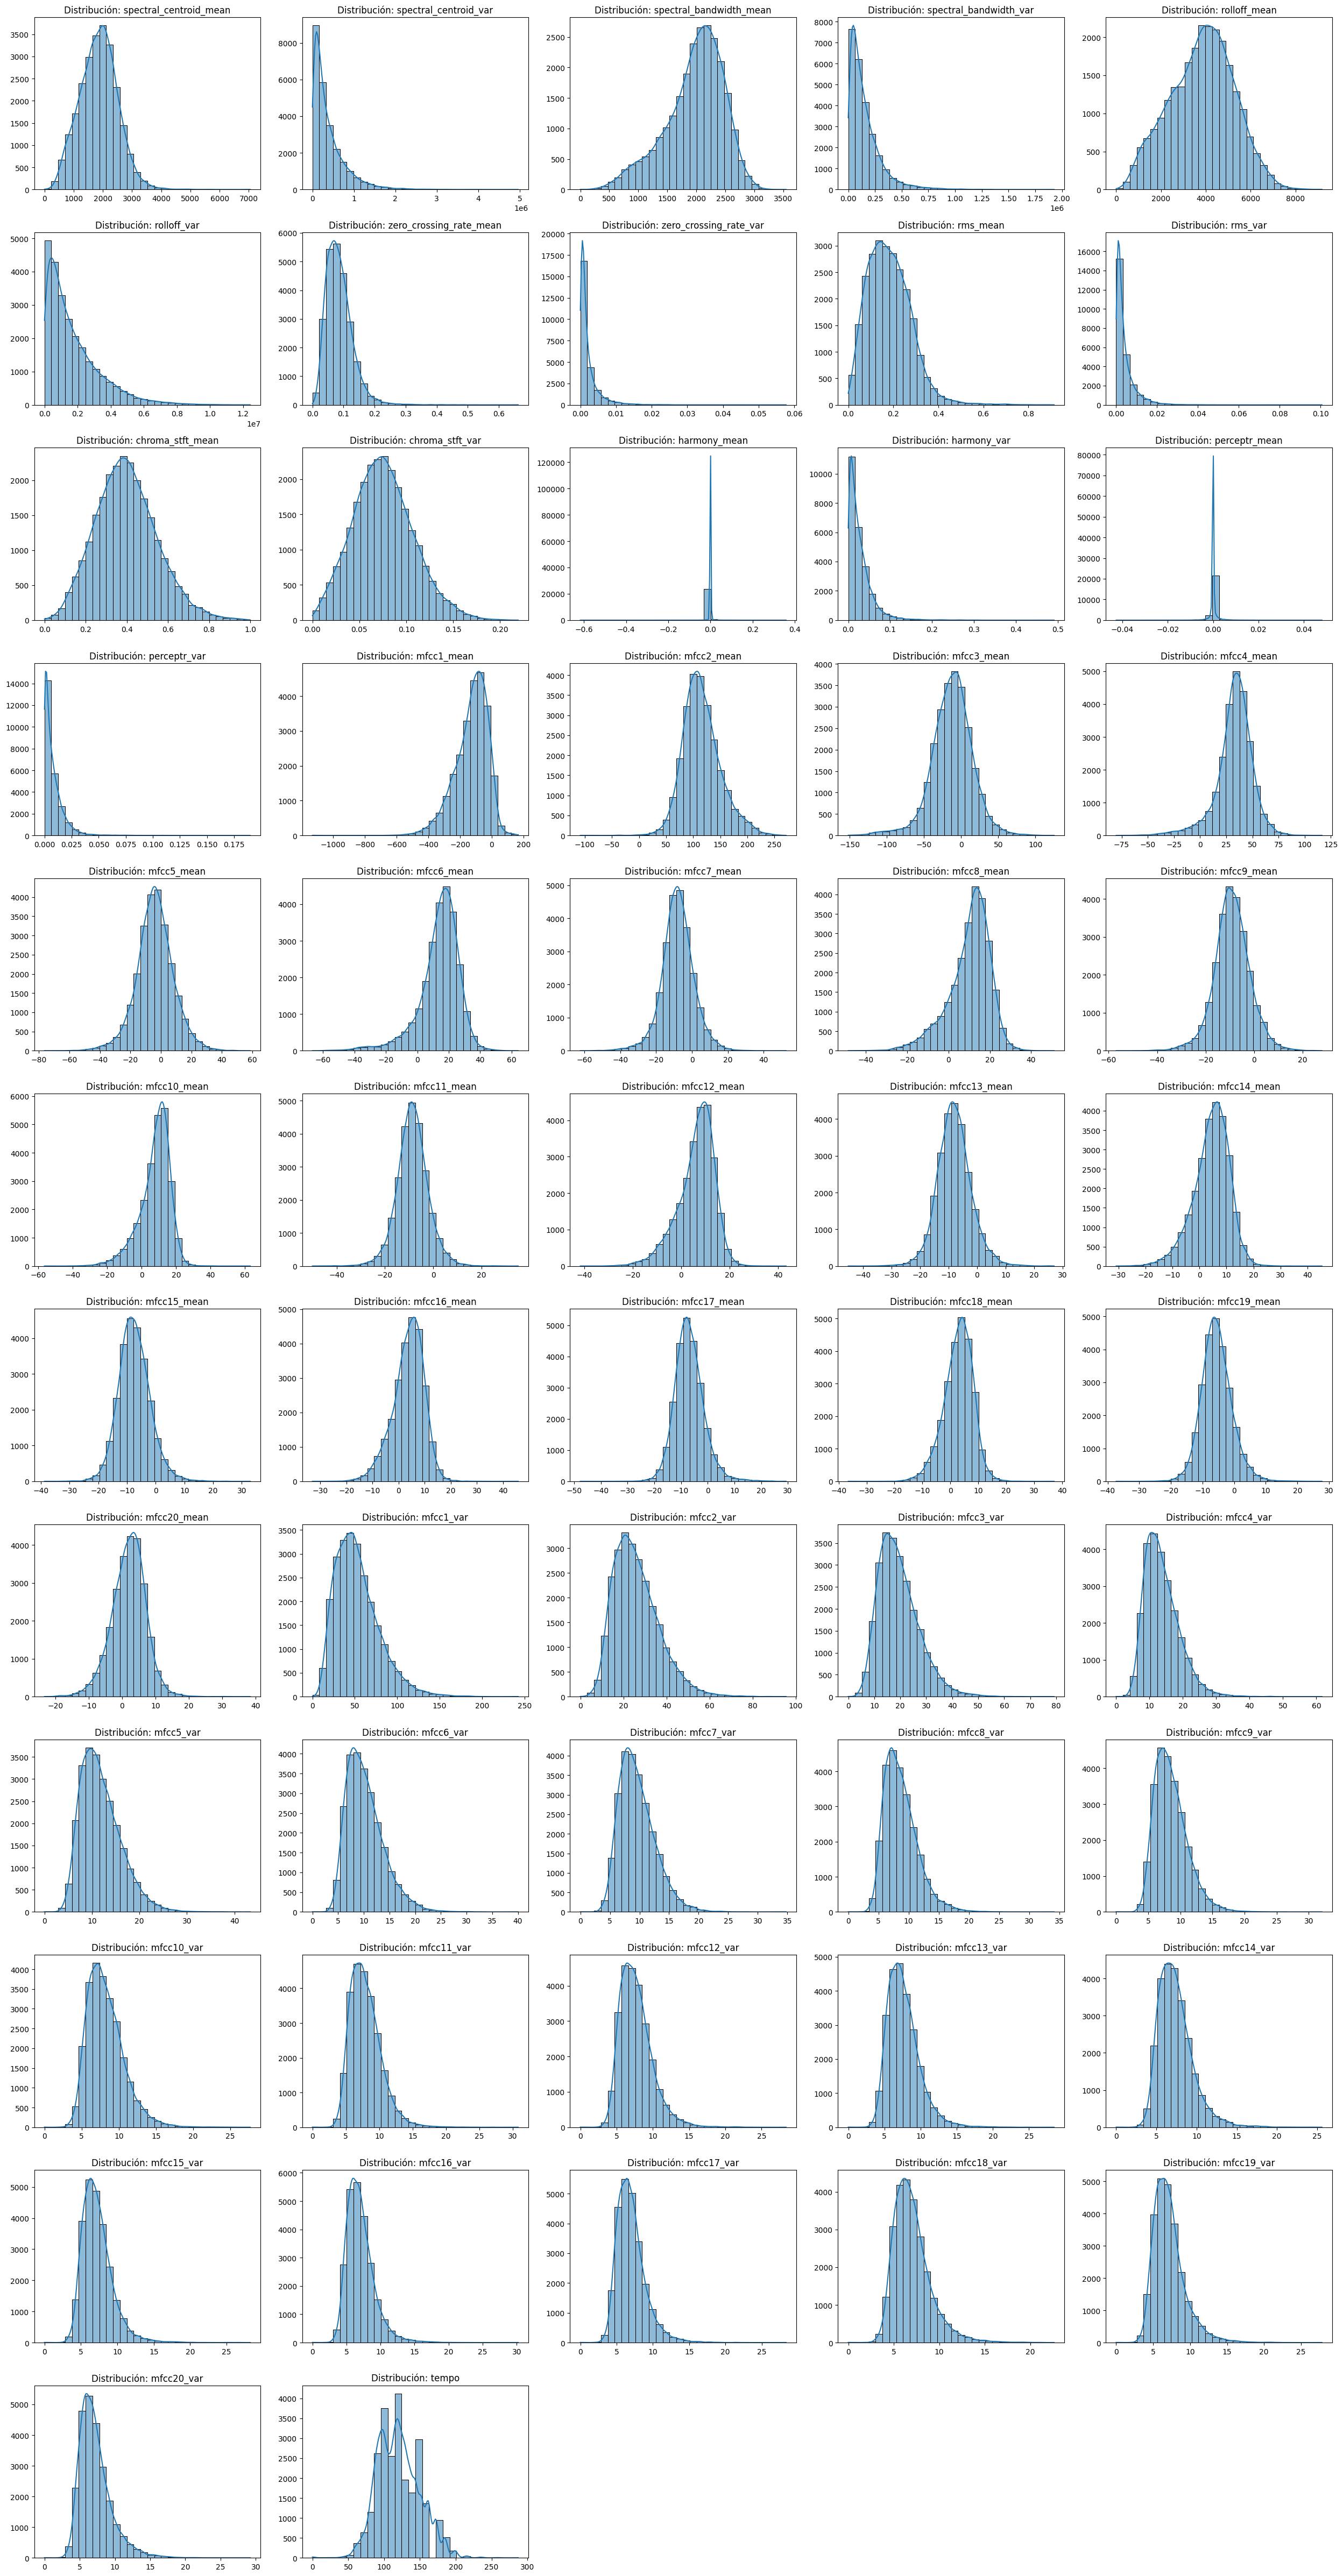

In [9]:
feature_cols = df.columns

feature_cols = [col for col in feature_cols if col != 'id']

num_features = len(feature_cols)
num_cols = 5
num_rows = (num_features + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    if i < len(axes):
        sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
        axes[i].set_title(f'Distribución: {col}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Asimetría

In [10]:
skewness_data = [] # datos de asimetría
for col in feature_cols: # Todas las columnas, menos id
    # Cálculo de asimetría
    skewness_data.append({'feature': col, 'skewness_value': skew(df[col])})

skewness_df = pd.DataFrame(skewness_data)

In [11]:
# Asimetrías mayores a 2 (sesgadas a la derecha)
skewness_high = skewness_df[skewness_df['skewness_value'] > 2]
display(skewness_high)

,feature,skewness_value
1,spectral_centroid_var,2.376431
3,spectral_bandwidth_var,2.362970
7,zero_crossing_rate_var,4.569928
9,rms_var,3.426131
13,harmony_var,3.283102
15,perceptr_var,3.947368


### Boxplots de variables con mayor asimetría

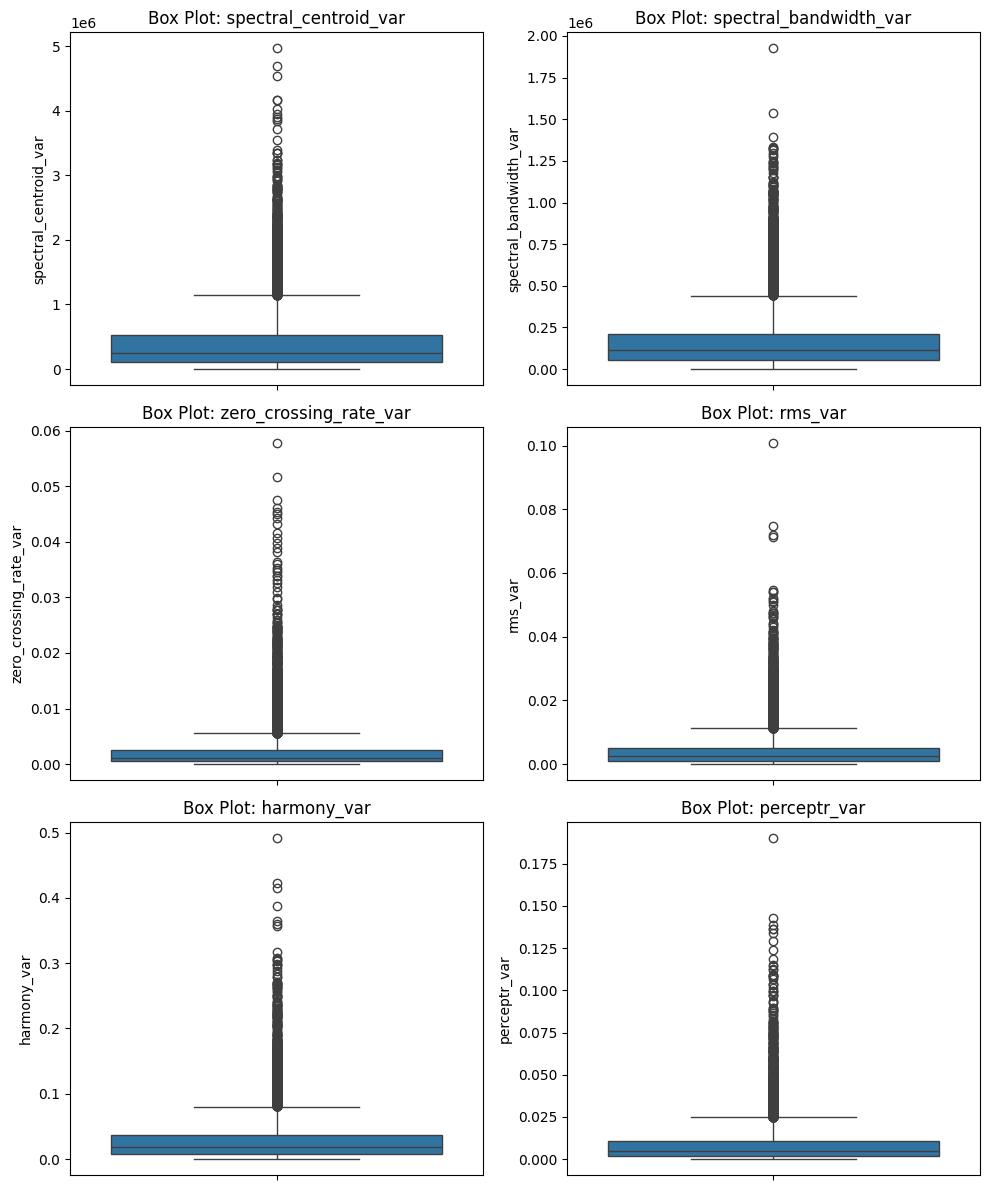

In [12]:
cols_to_trait = skewness_high['feature'].tolist()
num_features = len(cols_to_trait)

num_cols = 2
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))

axes = axes.flatten()

for i, col in enumerate(cols_to_trait):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot: {col}')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Correlación entre variables

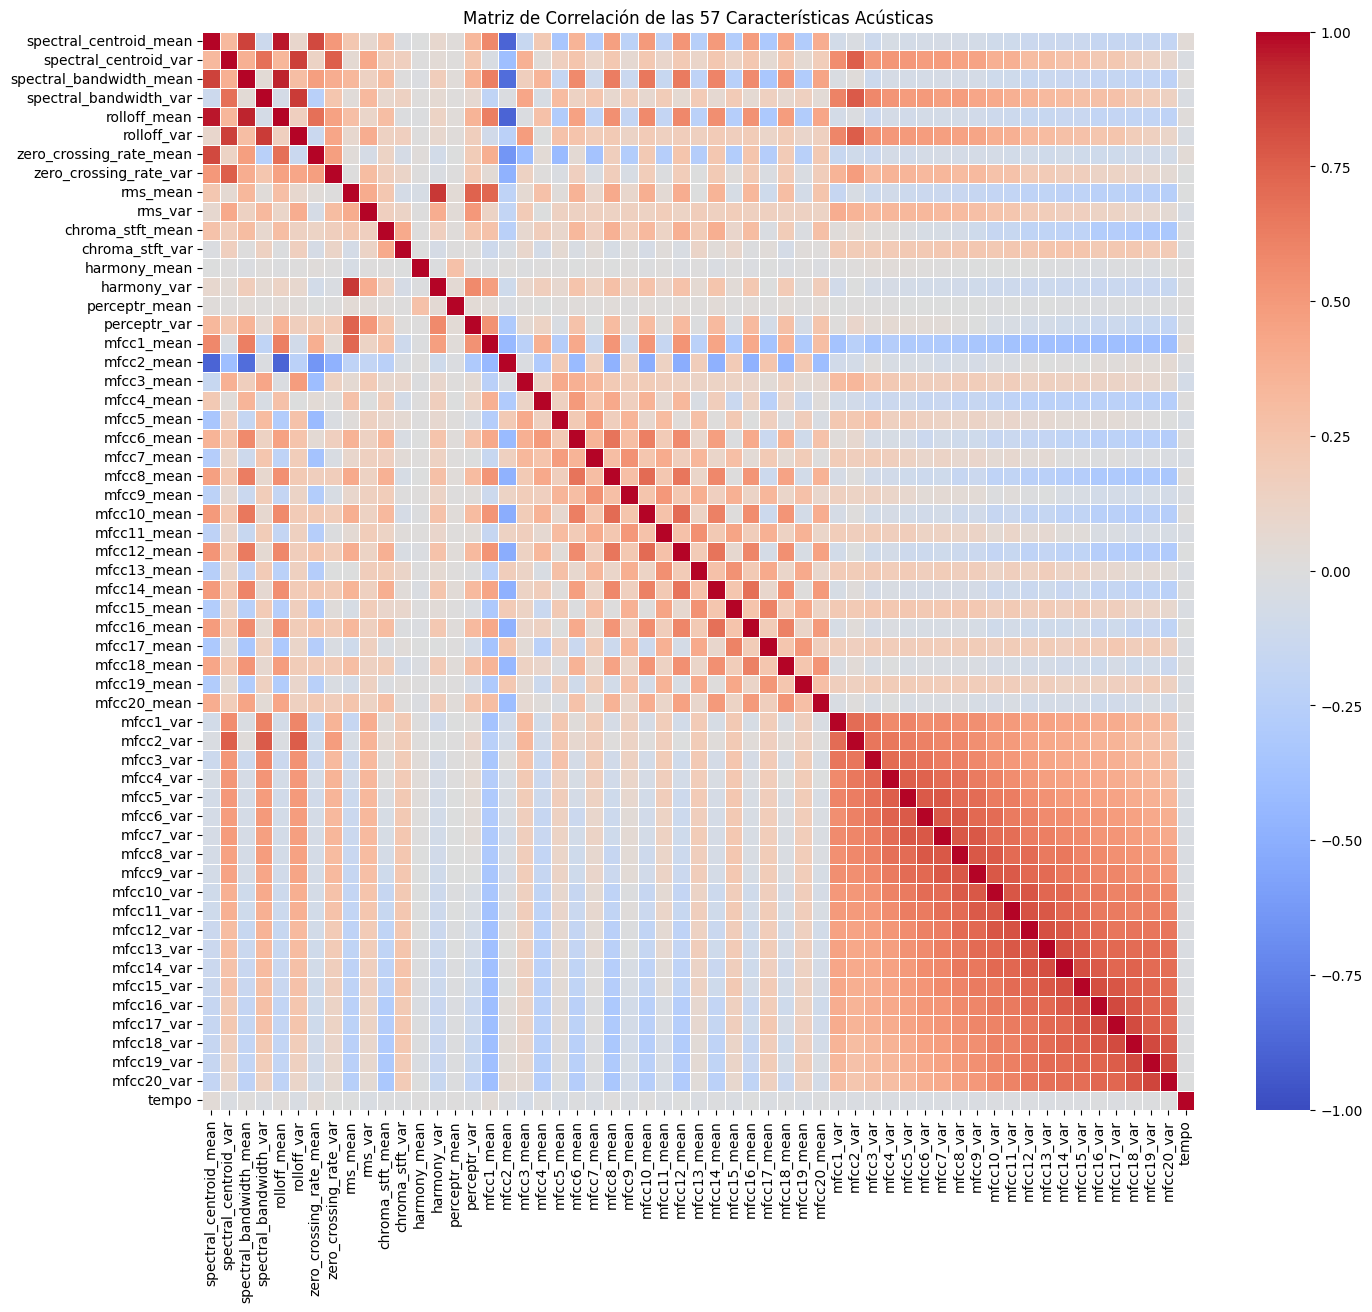

In [13]:
corr_matrix = df.corr()

plt.figure(figsize=(16, 14))

sns.heatmap(corr_matrix,
            annot=False,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            linewidths=.5)
plt.title('Matriz de Correlación de las 57 Características Acústicas')
plt.show()

In [14]:
corr_matrix = df.corr().abs()

threshold = 0.85

highly_correlated_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] >= threshold:
            colname1 = corr_matrix.columns[i]
            colname2 = corr_matrix.columns[j]
            correlation_value = corr_matrix.iloc[i, j]
            highly_correlated_pairs.append((colname1, colname2, correlation_value))

df_redundancy = pd.DataFrame(highly_correlated_pairs,
                             columns=['Característica 1', 'Característica 2', 'Correlación (|r|)'])

df_redundancy = df_redundancy.sort_values(by='Correlación (|r|)', ascending=False)

print(df_redundancy)

          Característica 1         Característica 2  Correlación (|r|)
1             rolloff_mean   spectral_centroid_mean           0.965758
2             rolloff_mean  spectral_bandwidth_mean           0.938742
6               mfcc2_mean   spectral_centroid_mean           0.890184
5              harmony_var                 rms_mean           0.888178
8               mfcc2_mean             rolloff_mean           0.885756
4              rolloff_var   spectral_bandwidth_var           0.882260
3              rolloff_var    spectral_centroid_var           0.862669
0  spectral_bandwidth_mean   spectral_centroid_mean           0.854824
7               mfcc2_mean  spectral_bandwidth_mean           0.850077


### Análisis PCA con datos en bruto

In [15]:
df_features = df.copy()


X_bruto = df_features.values

pca = PCA().fit(X_bruto)

In [16]:
var_explicada = pca.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

df_pca_var = pd.DataFrame({
    'Componente': range(1, len(var_explicada) + 1),
    'Varianza Explicada (%)': (var_explicada * 100).round(2),
    'Varianza Acumulada (%)': (var_acumulada * 100).round(2)
})

print("Resultados de Varianza de PCA (Datos Brutos):\n")
print(df_pca_var.head(10).to_markdown(index=False))

Resultados de Varianza de PCA (Datos Brutos):

|   Componente |   Varianza Explicada (%) |   Varianza Acumulada (%) |
|-------------:|-------------------------:|-------------------------:|
|            1 |                    98.36 |                    98.36 |
|            2 |                     1.48 |                    99.84 |
|            3 |                     0.16 |                   100    |
|            4 |                     0    |                   100    |
|            5 |                     0    |                   100    |
|            6 |                     0    |                   100    |
|            7 |                     0    |                   100    |
|            8 |                     0    |                   100    |
|            9 |                     0    |                   100    |
|           10 |                     0    |                   100    |


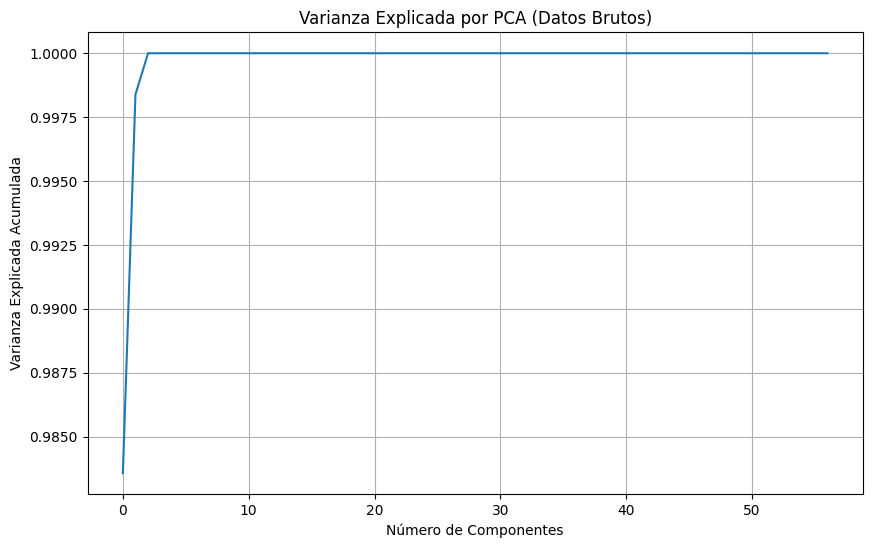

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada por PCA (Datos Brutos)')
plt.grid(True)
plt.show()

## Limpieza y corrección de datos

Se elimina la variable rolloff_mean por su alta correlación con spectral_centroid_mean y spectral_bandwidth_mean

In [97]:
df_tratamiento = df.copy()
df_tratamiento = df_tratamiento.drop('rolloff_mean', axis=1)

### Eliminación de outliers

In [98]:
# Definición de umbrales estadísticos (basados en tu análisis de cuantiles)
umbral_zcr_max = df_tratamiento['zero_crossing_rate_mean'].quantile(0.90)
umbral_harmony_min = df_tratamiento['harmony_mean'].quantile(0.10)
umbral_rms_min = df_tratamiento['rms_mean'].quantile(0.05)
umbral_mfcc1_min = df_tratamiento['mfcc1_mean'].quantile(0.01) # El 1% más extremo/erróneo

In [99]:
condicion_corrupto = (df_tratamiento['spectral_centroid_mean'] == 0) | \
                     (df_tratamiento['rms_mean'] == 0)

condicion_voz_ruido = (df_tratamiento['zero_crossing_rate_mean'] > umbral_zcr_max) & \
                      (df_tratamiento['harmony_mean'] < umbral_harmony_min)

condicion_estatica = (df_tratamiento['zero_crossing_rate_mean'] > 0.50)

condicion_energia = (df_tratamiento['mfcc1_mean'] < umbral_mfcc1_min) | \
                    (df_tratamiento['rms_mean'] < umbral_rms_min)

In [100]:
mask_outliers = condicion_corrupto | condicion_voz_ruido | condicion_estatica | condicion_energia

In [101]:
df_limpio = df_tratamiento[~mask_outliers].copy()

In [102]:
registros_eliminados = len(df_tratamiento) - len(df_limpio)

In [103]:
registros_eliminados

1522

Definición de umbrales para el Filtro Musical (Speech vs Music)
Usar los cuantiles para identificar el 10% con más ruido (ZCR)
y el 10% con menos estructura melódica (Harmony) *(JUSTIFICAR)*

In [104]:
# prueba de audio con voces
pd.set_option('display.max_columns', None)
filtered_df = df_limpio[df_limpio.index == 18391]
display(filtered_df)

,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_var,zero_crossing_rate_mean,zero_crossing_rate_var,rms_mean,rms_var,chroma_stft_mean,chroma_stft_var,harmony_mean,harmony_var,perceptr_mean,perceptr_var,mfcc1_mean,mfcc2_mean,mfcc3_mean,mfcc4_mean,mfcc5_mean,mfcc6_mean,mfcc7_mean,mfcc8_mean,mfcc9_mean,mfcc10_mean,mfcc11_mean,mfcc12_mean,mfcc13_mean,mfcc14_mean,mfcc15_mean,mfcc16_mean,mfcc17_mean,mfcc18_mean,mfcc19_mean,mfcc20_mean,mfcc1_var,mfcc2_var,mfcc3_var,mfcc4_var,mfcc5_var,mfcc6_var,mfcc7_var,mfcc8_var,mfcc9_var,mfcc10_var,mfcc11_var,mfcc12_var,mfcc13_var,mfcc14_var,mfcc15_var,mfcc16_var,mfcc17_var,mfcc18_var,mfcc19_var,mfcc20_var,tempo
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


In [105]:
df_tratamiento = df_limpio.copy()

### Corrección de asimetría y escalado

In [106]:
log_cols = skewness_high['feature'].tolist() # Generada en sección Asimetría

X = df_tratamiento.copy()

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [107]:
feature_columns = [col for col in X_train.columns]

Transformación logarítmica

In [108]:
for col in log_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

Estandarización

In [109]:
standard_scaler = StandardScaler()

In [110]:
for col in feature_columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')

X_train_clean = pd.DataFrame(standard_scaler.fit_transform(X_train[feature_columns]),
                                 columns=feature_columns,
                                 index=X_train.index)

In [111]:
for col in feature_columns:
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

X_test_clean = pd.DataFrame(standard_scaler.transform(X_test[feature_columns]),
                                columns=feature_columns,
                                index=X_test.index)

In [112]:
X_train_scaled = X_train_clean.values
X_test_scaled = X_test_clean.values

In [113]:
X_train_clean.head()

,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_var,zero_crossing_rate_mean,zero_crossing_rate_var,rms_mean,rms_var,chroma_stft_mean,chroma_stft_var,harmony_mean,harmony_var,perceptr_mean,perceptr_var,mfcc1_mean,mfcc2_mean,mfcc3_mean,mfcc4_mean,mfcc5_mean,mfcc6_mean,mfcc7_mean,mfcc8_mean,mfcc9_mean,mfcc10_mean,mfcc11_mean,mfcc12_mean,mfcc13_mean,mfcc14_mean,mfcc15_mean,mfcc16_mean,mfcc17_mean,mfcc18_mean,mfcc19_mean,mfcc20_mean,mfcc1_var,mfcc2_var,mfcc3_var,mfcc4_var,mfcc5_var,mfcc6_var,mfcc7_var,mfcc8_var,mfcc9_var,mfcc10_var,mfcc11_var,mfcc12_var,mfcc13_var,mfcc14_var,mfcc15_var,mfcc16_var,mfcc17_var,mfcc18_var,mfcc19_var,mfcc20_var,tempo
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
118626,0.690802,0.524558,0.972404,0.088671,0.000904,0.230761,0.458767,-1.461387,-0.669975,0.039055,0.795667,0.404105,-0.952926,0.917000,-0.699199,-0.882483,-0.791866,0.064377,-0.491569,-0.066098,0.538938,0.047528,0.496631,0.481999,1.010599,0.495820,0.433284,-0.152478,0.941787,0.287392,0.490385,0.059181,0.205857,0.266942,0.049420,0.264472,0.012811,0.440332,-0.097405,0.021397,0.506906,0.417578,0.209447,0.559270,0.655511,0.230500,-0.377120,-0.514406,-0.522254,-0.098157,-0.434596,-0.610156,-0.216166,-0.140540,0.019925,-1.436821
138013,-0.488588,0.502647,-0.288837,0.835397,0.103849,-0.635694,-0.218454,0.756173,0.026775,0.016939,-0.277223,-0.003248,0.495625,-1.628553,0.078347,0.535756,0.379999,-0.052186,0.939019,0.803982,-0.197813,0.331729,0.930613,1.381754,-0.685487,0.329713,0.007607,-0.494979,0.418602,0.296074,0.105223,-0.652516,-0.111736,0.866784,-0.260547,0.974403,0.928168,-0.036874,0.147119,0.349610,0.764933,-0.603700,-0.131794,-0.204634,1.576421,-0.652889,0.161340,-0.966577,0.010918,-0.332815,-0.346564,-0.007395,0.344082,-0.860795,0.259748,1.797506
55289,0.381508,0.974170,0.294685,0.912507,1.249764,0.484787,0.220930,0.256819,0.395927,-1.532916,-1.613131,0.004079,0.200940,-0.185922,-0.169037,0.720133,-0.156513,-0.113715,-1.046283,-1.182351,-0.061485,-1.461781,-0.893271,-1.048369,-0.470905,-1.356153,-0.578127,-1.189719,-0.270491,-0.885779,-0.123181,-0.073353,0.476050,0.484696,1.210152,0.748271,1.379000,0.184154,0.074683,0.278900,0.138005,-0.106706,0.656604,0.433119,0.723887,0.222300,0.642060,-0.099750,1.647861,0.567611,1.798644,-0.178120,-0.206712,0.092285,0.054626,0.549170
44193,-1.458578,-0.678626,-1.076304,0.183851,-0.448722,-1.223732,-0.674685,-1.098217,-0.702249,-0.514200,0.624996,0.006098,-0.796111,-0.056415,-0.763491,-1.305268,1.288157,0.365775,1.427212,1.033170,-0.358758,1.189482,-0.399121,0.152024,-0.024731,0.098631,-0.487585,1.386211,-0.867039,-0.738625,-1.537684,-0.556836,-1.023403,0.879105,0.221729,-0.300621,-0.701162,-0.202738,-0.516662,-0.304664,-0.497017,-0.724051,-0.504545,-0.563983,-1.012579,-0.816516,-0.569568,0.066068,-0.702834,-0.525229,-0.162927,-0.064297,-0.356758,0.403424,0.337262,1.797506
1555,-2.028358,-1.835580,-2.156842,-0.760166,-0.975737,-1.610755,-0.722082,0.126237,0.227701,-0.773895,1.075302,0.006131,0.389409,-0.039304,-0.691136,-1.107547,2.136092,0.527316,-0.722419,1.807729,-0.211094,1.005014,-1.263042,1.448376,-0.705951,1.738386,-1.169286,0.553678,-1.626132,0.282230,-1.366367,0.794999,-0.145612,0.649083,-2.158574,-0.820502,-0.859804,-0.655685,0.404322,-0.522852,-0.897928,-1.313247,-0.949506,-1.047741,-1.307991,-1.328344,-1.414793,-1.076204,-1.205808,-1.082546,-1.017128,-0.916557,-0.342383,-0.137813,-0.439695,-1.167293


### Análisis de PCA con datos escalados

In [114]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

var_explicada = pca.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

df_pca_var = pd.DataFrame({
    'Componente': range(1, len(var_explicada) + 1),
    'Varianza Explicada (%)': (var_explicada * 100).round(2),
    'Varianza Acumulada (%)': (var_acumulada * 100).round(2)
})

print("Resultados de Varianza de PCA (Datos Brutos):\n")
print(df_pca_var.head(30).to_markdown(index=False))

Resultados de Varianza de PCA (Datos Brutos):

|   Componente |   Varianza Explicada (%) |   Varianza Acumulada (%) |
|-------------:|-------------------------:|-------------------------:|
|            1 |                    26.19 |                    26.19 |
|            2 |                    16.06 |                    42.25 |
|            3 |                     9.03 |                    51.29 |
|            4 |                     5.22 |                    56.5  |
|            5 |                     4.08 |                    60.58 |
|            6 |                     3.84 |                    64.42 |
|            7 |                     2.56 |                    66.97 |
|            8 |                     2.36 |                    69.33 |
|            9 |                     2.25 |                    71.58 |
|           10 |                     1.78 |                    73.36 |
|           11 |                     1.69 |                    75.05 |
|           12 |              

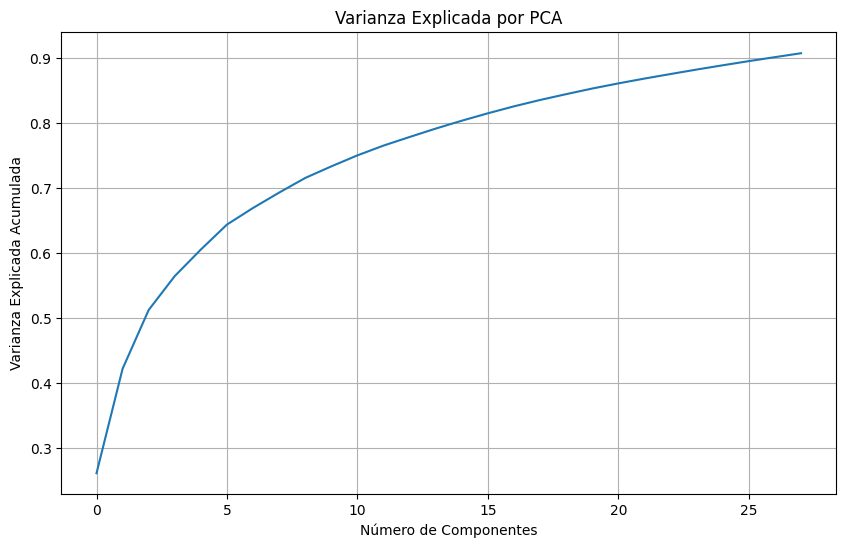

In [137]:
plt.figure(figsize=(10, 6))

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada por PCA')
plt.grid(True)
plt.show()

### Reducción a 28 componentes

In [116]:
df_original_escalado = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train.index)

In [117]:
pca = PCA(n_components=28)
X_train_scaled = pca.fit_transform(X_train_scaled)
X_test_scaled = pca.transform(X_test_scaled)

In [118]:
n_componentes = pca.n_components_
columnas_pca = [f'PC{i+1}' for i in range(n_componentes)]

X_train_clean = pd.DataFrame(
    X_train_scaled,
    columns=columnas_pca,
    index=X_train_clean.index
)

X_test_clean = pd.DataFrame(
    X_test_scaled,
    columns=columnas_pca,
    index=X_test_clean.index
)

## Determinar mejor K - Método del codo

In [119]:
rango_k = range(1, 20)
inercia = []

X_train_scaled_cleaned = np.nan_to_num(X_train_scaled, nan=0.0, posinf=np.finfo(np.float64).max, neginf=np.finfo(np.float64).min)
X_test_scaled_cleaned = np.nan_to_num(X_test_scaled, nan=0.0, posinf=np.finfo(np.float64).max, neginf=np.finfo(np.float64).min)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled_cleaned)
    inercia.append(kmeans.inertia_)

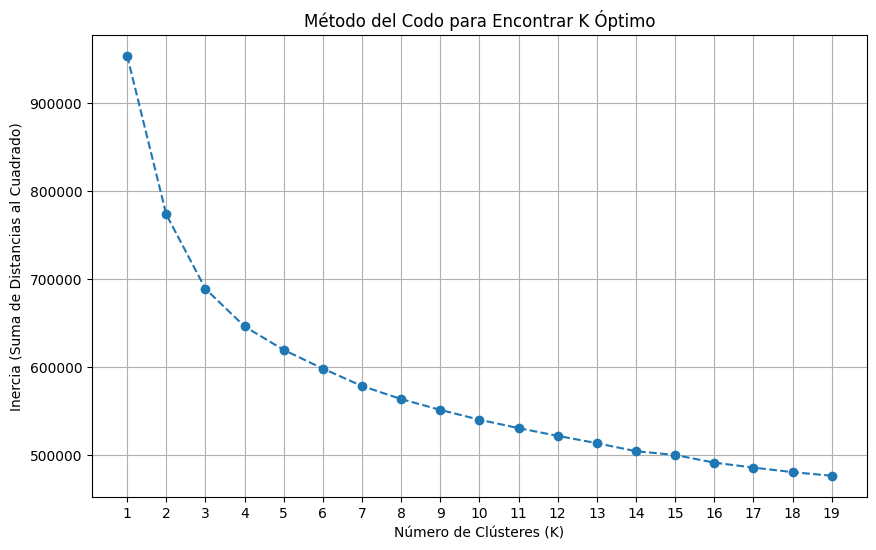

In [120]:
plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, marker='o', linestyle='--')
plt.title('Método del Codo para Encontrar K Óptimo')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (Suma de Distancias al Cuadrado)')
plt.xticks(rango_k)
plt.grid(True)
plt.show()

## K-means

In [121]:
K_optimo = 5

kmeans_final = KMeans(n_clusters=K_optimo, init='k-means++', random_state=42, n_init=10)
kmeans_final.fit(X_train_scaled_cleaned)

cluster_labels_train = kmeans_final.labels_

X_train_clean['cluster_label'] = cluster_labels_train

df_original_escalado['cluster_label'] = cluster_labels_train

centroides = kmeans_final.cluster_centers_

print(f"Modelo K-Means entrenado exitosamente con K={K_optimo}.")
print(f"Distribución de canciones por clúster en el conjunto de entrenamiento:")
print(X_train_clean['cluster_label'].value_counts().sort_index())
print("\nLos centroides del modelo han sido guardados para la búsqueda rápida en la Fase 2.")

Modelo K-Means entrenado exitosamente con K=5.
Distribución de canciones por clúster en el conjunto de entrenamiento:
cluster_label
0    5347
1    2632
2    5551
3    2832
4    2404
Name: count, dtype: int64

Los centroides del modelo han sido guardados para la búsqueda rápida en la Fase 2.


In [123]:
# Asignar etiquetas de clúster a X_test
cluster_labels_test = kmeans_final.predict(X_test_scaled_cleaned)
X_test_clean['cluster_label'] = cluster_labels_test

## Crear diccionarios de modelos para exportar


In [124]:
# Diccionario para guardar un buscador por cada clúster
dict_modelos_knn = {}

# Clústeres únicos
clusters_unicos = X_train_clean['cluster_label'].unique()

features_audio = [col for col in X_train_clean.columns if col != 'cluster_label']

for cluster_id in clusters_unicos:
    # Filtrar los datos que pertenecen a este clúster
    df_cluster = X_train_clean[X_train_clean['cluster_label'] == cluster_id]

    # Extraer las 56 variables de audio
    X_cluster = df_cluster[features_audio].values

    # Cuántos vecinos buscar
    n_vecinos = min(2, X_cluster.shape[0])

    # Entrenar el modelo KNN para este subconjunto
    knn = NearestNeighbors(n_neighbors=n_vecinos, metric='cosine', algorithm='brute')
    knn.fit(X_cluster)

    # Guardar el modelo en el diccionario
    dict_modelos_knn[cluster_id] = knn

## Descripción de clústeres

In [125]:
features_radar = ['tempo', 'rms_mean', 'spectral_centroid_mean', 'harmony_mean', 'zero_crossing_rate_mean']
df_radar = df_original_escalado.groupby('cluster_label')[features_radar].mean().reset_index()

fig = go.Figure()
for i in range(len(df_radar)):
    fig.add_trace(go.Scatterpolar(
        r=df_radar.loc[i, features_radar].values,
        theta=features_radar,
        fill='toself',
        name=f'Clúster {int(df_radar.loc[i, "cluster_label"])}'
    ))

fig.update_layout(title="Análisis Tímbrico por Clúster")
fig.show()

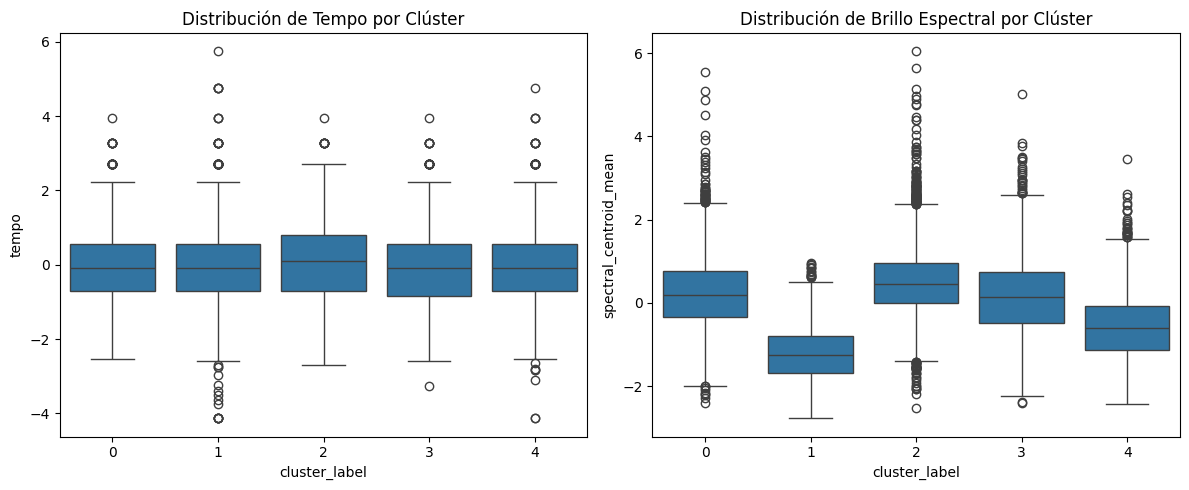

In [126]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='cluster_label', y='tempo', data=df_original_escalado)
plt.title('Distribución de Tempo por Clúster')

plt.subplot(1, 2, 2)
sns.boxplot(x='cluster_label', y='spectral_centroid_mean', data=df_original_escalado)
plt.title('Distribución de Brillo Espectral por Clúster')

plt.tight_layout()
plt.show()

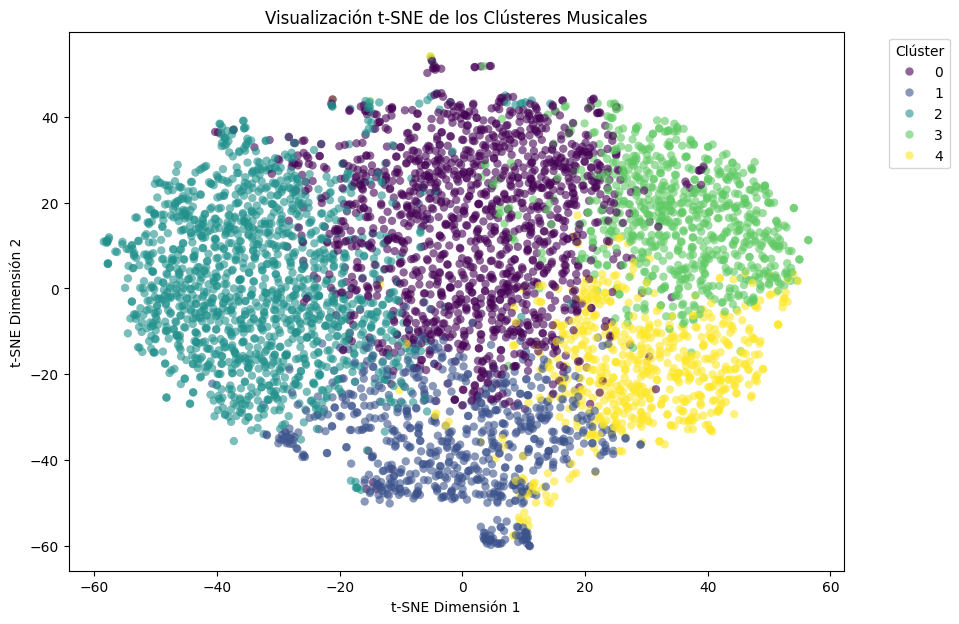

In [136]:
X_sample = df_original_escalado.sample(5000, random_state=42)

labels_sample = X_sample['cluster_label']

features_sample = X_sample.drop('cluster_label', axis=1)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(features_sample)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=labels_sample,
    palette='viridis',
    alpha=0.6,
    edgecolor='none'
)
plt.title('Visualización t-SNE de los Clústeres Musicales')
plt.xlabel('t-SNE Dimensión 1')
plt.ylabel('t-SNE Dimensión 2')
plt.legend(title='Clúster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Calidad del Agrupamiento (Silueta)


In [128]:
sample_silhouette_values = silhouette_samples(features_sample, labels_sample)

score = silhouette_score(features_sample, labels_sample)

print(f"--- Evaluación del Agrupamiento ---")
print(f"Coeficiente de Silueta Total: {score:.4f}")

# 4. Iterar usando las etiquetas de la MUESTRA (que ahora miden lo mismo: 5000)
for i in range(5):
    # Filtramos los valores de la silueta usando las etiquetas de la misma muestra
    ith_cluster_silhouette_values = sample_silhouette_values[labels_sample == i]

    if len(ith_cluster_silhouette_values) > 0:
        print(f"Silueta Promedio Clúster {i}: {np.mean(ith_cluster_silhouette_values):.4f}")
    else:
        print(f"Silueta Promedio Clúster {i}: Sin datos en la muestra")

--- Evaluación del Agrupamiento ---
Coeficiente de Silueta Total: 0.0917
Silueta Promedio Clúster 0: 0.0825
Silueta Promedio Clúster 1: 0.0399
Silueta Promedio Clúster 2: 0.1748
Silueta Promedio Clúster 3: 0.0432
Silueta Promedio Clúster 4: 0.0339


## Simulación

In [132]:
def recomendar_canciones_hibridas(song, modelo_kmeans, dict_modelos_knn, df_train, k=3):
    song_reshaped = song.reshape(1, -1)

    # Identificar el clúster
    cluster_asignado = modelo_kmeans.predict(song_reshaped)[0]

    # Modelo KNN pre-entrenado para ese clúster específico
    knn_modelo = dict_modelos_knn[cluster_asignado]

    # Búsqueda K-NN Local k+1 para poder filtrar la canción de origen si es necesario
    distancias, indices = knn_modelo.kneighbors(song_reshaped, n_neighbors=k+1)

    # IDs reales desde el subset del DataFrame original
    df_cluster_subset = df_train[df_train['cluster_label'] == cluster_asignado]

    # Extracción de índices basándonos en la posición local devuelta por el KNN
    ids_recomendados = df_cluster_subset.index[indices[0]].tolist()

    # k canciones más cercanas (quitando la primera si es la misma)
    return ids_recomendados[1:k+1]

### Evaluación de la Calidad de la Recomendación (Distancia y Eficiencia)

In [133]:
# Función para recomendación aleatoria (Baseline)
def recomendar_aleatorio(df_train, k=3):
    return df_train.sample(k).index.tolist()

# Configuración de la prueba (100 consultas para promediar)
n_pruebas = 100
indices_test = np.random.choice(len(X_test_scaled), n_pruebas, replace=False)

latencias_hibrido = []
latencias_estandar = []
distancias_hibrido = []
distancias_random = []

# Preparar KNN Estándar para la comparativa
knn_estandar = NearestNeighbors(n_neighbors=2, metric='cosine', algorithm='brute').fit(X_train_scaled)

for idx in indices_test:
    x_query = X_test_scaled[idx].reshape(1, -1)

    # Prueba Híbrido
    start = time.time()
    recs_hibrido_ids = recomendar_canciones_hibridas(x_query[0], kmeans_final, dict_modelos_knn, X_train_clean, k=3)
    latencias_hibrido.append(time.time() - start)

    # Medir distancias del híbrido
    recs_vectores = X_train_clean.loc[recs_hibrido_ids].drop('cluster_label', axis=1).values
    dist_h = np.mean([np.linalg.norm(x_query - r) for r in recs_vectores])
    distancias_hibrido.append(dist_h)

    # Prueba K-NN Estándar
    start = time.time()
    _, _ = knn_estandar.kneighbors(x_query)
    latencias_estandar.append(time.time() - start)

    # Prueba Aleatoria (Baseline de precisión)
    recs_rand_ids = recomendar_aleatorio(X_train_clean, k=3)
    recs_rand_vectores = X_train_clean.loc[recs_rand_ids].drop('cluster_label', axis=1).values
    dist_r = np.mean([np.linalg.norm(x_query - r) for r in recs_rand_vectores])
    distancias_random.append(dist_r)

print(f"--- Comparativa de Eficiencia (Latencia) ---")
print(f"Tiempo promedio Híbrido: {np.mean(latencias_hibrido):.6f} seg")
print(f"Tiempo promedio K-NN Estándar: {np.mean(latencias_estandar):.6f} seg")
print(f"Mejora de velocidad: {np.mean(latencias_estandar) / np.mean(latencias_hibrido):.2f}x más rápido")

print(f"\n--- Comparativa de Precisión (cosine) ---")
print(f"Distancia promedio Híbrido: {np.mean(distancias_hibrido):.4f}")
print(f"Distancia promedio Aleatorio: {np.mean(distancias_random):.4f}")
print(f"Mejora en cercanía acústica: {((np.mean(distancias_random) - np.mean(distancias_hibrido)) / np.mean(distancias_random)) * 100:.2f}%")

--- Comparativa de Eficiencia (Latencia) ---
Tiempo promedio Híbrido: 0.003968 seg
Tiempo promedio K-NN Estándar: 0.005456 seg
Mejora de velocidad: 1.37x más rápido

--- Comparativa de Precisión (Distancia Euclidiana) ---
Distancia promedio Híbrido: 4.3318
Distancia promedio Aleatorio: 9.5070
Mejora en cercanía acústica: 54.44%


## Guardar para Flask

In [134]:
modeloKmeans = 'modeloKmeans_20abril2026.joblib'
standardScaler = 'standardScaler_20abril2026.joblib'
modelosKnn = 'modelosKnnClusters_20abril2026.joblib'
# Guardar el modelo entrenado
joblib.dump(kmeans_final, modeloKmeans)

# Guardar el escalador (ej. RobustScaler o StandardScaler)
joblib.dump(standard_scaler, standardScaler)

# Modelos knn para cada cluster
joblib.dump(dict_modelos_knn, modelosKnn)

['modelosKnnClusters_20abril2026.joblib']

In [51]:
print(f" Diccionario KNN generado con {len(features_audio)} características.")

 Diccionario KNN generado con 28 características.


## Extractor de enlaces de drive

In [ ]:
# Montar Drive
drive.mount('/content/drive')

# Autenticación para usar la API de Drive
auth.authenticate_user()
drive_service = build('drive', 'v3')

In [ ]:
# https://drive.google.com/drive/folders/1JW4XDk26TeHYUGoYzZoXAb_JF-EKozaC?usp=drive_link
FOLDER_ID = '1JW4XDk26TeHYUGoYzZoXAb_JF-EKozaC'

def get_drive_files(folder_id):
    query = f"'{folder_id}' in parents and trashed = false"
    results = drive_service.files().list(q=query, fields="files(id, name, mimeType)").execute()
    return results.get('files', [])

In [ ]:
all_music_data = []

subfolders = get_drive_files(FOLDER_ID)

In [ ]:
contador = 0

In [ ]:
def get_all_subfolders(parent_id):
    query = f"'{parent_id}' in parents and mimeType = 'application/vnd.google-apps.folder' and trashed = false"
    subfolders = []
    page_token = None

    while True:

        response = drive_service.files().list(
            q=query,
            spaces='drive',
            fields='nextPageToken, files(id, name, mimeType)', # <-- AGREGAR mimeType AQUÍ
            pageToken=page_token
        ).execute()

        subfolders.extend(response.get('files', []))
        page_token = response.get('nextPageToken')

        if not page_token:
            break

    return subfolders

subfolders = get_all_subfolders(FOLDER_ID)
print(len(subfolders))

In [ ]:
for sub in subfolders:
    if sub['mimeType'] == 'application/vnd.google-apps.folder':
        print(f"Procesando carpeta: {sub['name']}")
        files_in_sub = get_drive_files(sub['id'])

        for f in files_in_sub:
            if f['name'].endswith('.mp3'):
              contador = contador+1
                #track_id = f['name'].split('.')[0]

                # Crear el enlace de reproducción directa
                #direct_link = f"https://drive.google.com/uc?id={f['id']}&export=download"

                #all_music_data.append({
                 #   'track_id': track_id,
                  #  'drive_id': f['id'],
                  #  'stream_url': direct_link,
                  #  'folder': sub['name']
               # })

In [ ]:
contador

In [ ]:
mapeoFile = 'mapeo_drive.csv'
mapping_df = pd.DataFrame(all_music_data)
mapping_df.to_csv(mapeoFile, index=False)
print("Rutas listas")

## Descarga de archivos

In [135]:
# Descargar modelo
descargar = False
if descargar:
  files.download(modeloKmeans)
  files.download(standardScaler)
  files.download(modelosKnn)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>